# MVP -  Machine Learning e Analytics

**Autora:** Ligia R. Vieira  

**Matrícula:** 1200158

**Data:** Junho/2026


**Dataset:** [Stock Market Trends and Investor Sentiment](https://www.kaggle.com/datasets/dastgeerjutt/stock-market-trends-and-investor-sentiment?resource=download)

**Tipo de problema:** Classificação

# Definição do Problema

O mercado financeiro é influenciado diariamente por diversos fatores econômicos, políticos e comportamentais que interferem nos preços dos ativos. Tradicionalmente, os agentes do mercado financeiro tomavam as suas decisões baseadas em três pilares: Análise Fundamentalista, Análise Gráfica e Informações Econômicas e Notícias.


No contexto atual, temos o crescimento exponencial da disponibilização de dados que aliado à aplicação de modelos de Machine Learning possibilita a geração de previsões sobre o comportamento dos ativos.


Essa solução atenderia aos diversos agentes do mercado: Investidores, Analistas e Gestores Financeiros.


A relevância do problema está na possibilidade de gerar um dado de preditivo em informação útil para auxiliar decisões financeiras.
<br>
## Objetivo

O objetivo deste projeto é construir e avaliar um modelo de **<i>Classificação Binária**</i> utilizando o Dataset<i> Stock Market Trends and Investor Sentiment</i> para prever se o preço de um ativo financeiro apresentará alta ou baixa no período seguinte.

## Tipo do Problema

O Dataset possui algumas variáveis históricas:

Variáveis de preço:<br>

- open_price (preço de abertura)<br>
- high_price (preço máximo do período)<br>
- low_price(preço mínimo do período)<br>
- close_price (preço de fechamento)<br>

Volume negociações:<br>

- volume (quantidade negociada)<br>



Uma variável alvo (target) definida pode resultar em apenas duas categorias possíveis:

1 (Alta) → quando o preço de fechamento seguinte for superior ao preço do período atual.<br>
0 (Baixa) → quando o preço de fechamento seguinte for inferior ao preço do período atual.

Com isso, o problema proposto neste projeto é caracterizado como <i><u>Classificação Supervisionada Binária</u></i>.

Observação: Futuramente pretende-se explorar técnicas de Séries Temporais, mais adequadas à natureza dos dados, para enriquecimento do portfólio no GitHub.
<br><br>


# Hipóteses do Problema

1 - Os atributos de preço (open_price, high_price, low_price e close_price) contêm padrões históricos capazes de ajudar na previsão da direção do preço de fechamento no período seguinte.<br>
2 - O atributo market_sentiment melhora a capacidade do modelo de classificar a direção futura do preço.<br>
3 - O atributo volume contribui para identificar movimentos de alta ou baixa dos ativos.<br>
4 - A variável date pode conter padrões temporais relevantes para a previsão da direção do preço dos ativos.<br>
5 - A variável company pode capturar diferenças de comportamento entre os ativos, contribuindo para a classificação entre Alta (1) e Baixa (0).<br>


Como critério de sucesso, a métrica principal será o F1-score, pois o problema é de classificação binária e pode haver desbalanceamento entre classes (Alta e Baixa). O F1-score permite avaliar o equilíbrio entre precisão e recall, sendo mais adequado do que apenas accuracy.

# Ambiente, bibliotecas e reprodutibilidade


Este projeto foi desenvolvido em ambiente Python, utilizando o Google Colab para execução do notebook.

Também foram utilizadas bibliotecas mais utilizadas na área de Ciência de Dados como: Pandas, NumPy, Matplotlib, Seaborn e Scikit-learn.

A reprodutibilidade foi garantida pela definição de seed aleatória, uso de bibliotecas padrão necessárias em um pipeline com: carga dos dados, pré-processamento, modelagem e avaliação.

In [1]:


# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

# Pré-processamento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Métricas
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# Configurações
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

## Funções auxiliares

Função de avaliação de modelo

In [2]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall:", recall_score(y_test, y_pred))
    print("F1-score:", f1_score(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.show()

    #  Função de split

    def prepare_data(X, y):
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    return X_train, X_test, y_train, y_test

IndentationError: expected an indented block after function definition on line 15 (2547260279.py, line 16)

# Seleção e carga dos dados

O Dataset escolhido foi obtido no repositório Kaggle, sendo um conjunto de dados público e previamente estruturado. Dessa forma, o foco do trabalho concentra-se na execução do fluxo de aprendizado de máquina.
<br><br>
Link de acesso: https://www.kaggle.com/datasets/dastgeerjutt/stock-market-trends-and-investor-sentiment

Este Dataset foi escolhido por estar inserido no contexto do mercado financeiro, uma área de grande abrangência e relevância global, além de possibilitar a aplicação de técnicas de Machine Learning para gerar previsões sobre o comportamento dos ativos.

<b>A princípio, não existe restrições/condições...</b>

## Carga dos dados


In [2]:
# Acesso ao Dataset pelo Github

url = "https://raw.githubusercontent.com/Vieiraligia/Data-Science-and-Analytics/main/MVP%20Machine%20Learning%20e%20Analytics/stock_market_trends_5000.csv"

df = pd.read_csv(url)

In [3]:
display(HTML("<h3 style='text-align:center;'>Primeiras 7 linhas do Dataset</h3>"))
df.head(7)

,date,company,open_price,high_price,low_price,close_price,volume,market_sentiment
0,2015-01-01,Tesla,1305.33,75.86,966.61,1457.35,25927814,Bearish
1,2015-01-02,Google,391.80,686.82,593.58,883.22,22040434,Neutral
2,2015-01-03,Netflix,985.74,1275.50,1253.30,1131.63,36551427,Bullish
3,2015-01-04,Amazon,514.78,299.75,441.69,222.58,43823086,Bullish
4,2015-01-05,Amazon,779.04,657.66,1301.97,1453.85,38410461,Neutral
5,2015-01-06,Tesla,408.37,1098.67,1081.54,698.39,3531470,Neutral
6,2015-01-07,Google,89.33,789.22,809.52,1241.98,46672942,Bullish


## Atributos do Dataset


Variável temporal:<br>

- date → variável do tipo data/hora

Variável categórica:<br>
- company → variável categórica

Variáveis numéricas - features:<br>

- open_price (preço de abertura) → variável numérica contínua (float)<br>
- high_price (preço máximo do período) → variável numérica contínua (float)<br>
- low_price(preço mínimo do período) → variável numérica contínua (float)<br>
- close_price (preço de fechamento) → variável numérica contínua (float)<br>
- volume (quantidade negociada)→ variável numérica contínua (integer)<br>

Sentimento de mercado:<br>

- market_sentiment → variável categórica
<br>


##Total e Tipo das Instâncias

In [4]:
print("Total de instâncias:", len(df))
print("Total de atributos:", len(df.columns))
print("Tipos de dados: \n")

display(df.dtypes.to_frame("tipo"))

Total de instâncias: 5000
Total de atributos: 8
Tipos de dados: 



,tipo
date,object
company,object
open_price,float64
high_price,float64
low_price,float64
close_price,float64
volume,int64
market_sentiment,object


In [5]:
display(HTML("<h3 style='text-align:center;'>Verificação dos Dados</h3>"))

display(HTML("<h4>Valores Nulos</h4>"))
display(df.isna().sum())

display(HTML("<h4>Registros Duplicados:</h4>"))
display(df.duplicated().sum())

,0
date,0
company,0
open_price,0
high_price,0
low_price,0
close_price,0
volume,0
market_sentiment,0


np.int64(0)

A verificação realizada indica que não há valores ausentes em nenhum dos atributos e também não foram identificadas instâncias duplicadas no conjunto de dados.

In [6]:
 SEED = 1
display(df.sample(5, random_state=SEED))

,date,company,open_price,high_price,low_price,close_price,volume,market_sentiment
2764,2022-07-27,Amazon,508.65,551.90,1008.53,1247.64,37916291,Bullish
4767,2028-01-20,Apple,620.33,880.41,174.75,1138.44,31653727,Bullish
3814,2025-06-11,Meta,892.70,1192.14,1436.08,494.28,43863433,Bullish
3499,2024-07-31,Apple,138.42,1490.63,1133.23,1241.19,28785789,Bearish
2735,2022-06-28,Tesla,1095.47,585.32,1120.09,662.42,639421,Bullish


## Dicionário de Dados


| Coluna | Tipo  | Descrição  | Será usada no modelo? | Observações |
|---|---|---|---|---|
| date  | data | Data da observação do ativo financeiro                                   | Sim           | Usada para ordenação temporal e possível feature engineering |
| company  | categórica | Identificador da empresa/ativo  | Sim    | - |
| open_price   | numérica  | Preço de abertura do ativo no período  | Sim | Dados de preço  |
| high_price  | numérica | Maior preço atingido no período | Sim  | - |
| low_price  | numérica | Menor preço atingido no período   | Sim  | - |
| close_price  | numérica | Preço de fechamento do ativo  | Sim  | Base para o target |
| volume   | numérica | Volume de negociações realizadas | Sim  | - |
| market_sentiment | categórica/numérica | Indicador de sentimento do mercado    | Sim   | Talvez tenha encoding ou normalização |
| target  | binária (alvo)  | 1 = valorização do ativo, 0 = desvalorização ou estabilidade  | Alvo  | Dado que o modelo irá prever |

# Análise Exploratória dos Dados

Neste projeto, a Análise Exploratória de Dados tem por objetivo compreender a estrutura, a qualidade e as características dos dados, identificando aspectos erlevantes para a construção do modelo de Classificação Binária.

Mais especificamente, como mencionado na definição do problema, visa identificar quais variáveis apresentam características que podem ajudar o modelo a prever se o preço do ativo irá subir ou cair no próximo período.

Para isso, serão analisadas:
- Distribuição da variável alvo (Target).
- Distribuição das variáveis numéricas.
- Relação entre variáveis e o Target.
- Desbalanceamento, outliers ou padrões relevantes

###Distribuição da variável alvo (Target)

In [14]:
# variável alvo
# 1 = Alta e 0 = Baixa

df["Target"] = (df["close_price"].shift(-1) > df["close_price"]).astype(int)

# não existe close_price(t+1) tirar
df = df.iloc[:-1]

In [15]:
# frequência das classes em % e total

target_summary = pd.DataFrame({
    "Frequência": df["Target"].value_counts().sort_index(),
    "Percentual (%)": (df["Target"].value_counts(normalize=True).sort_index()*100).round(2)
})

target_summary.index = ["Baixa (0)", "Alta (1)"]

target_summary

,Frequência,Percentual (%)
Baixa (0),2497,49.96
Alta (1),2501,50.04


A variável Target apresenta distribuição equilibrada entre as classes Alta (1) e Baixa (0), com aproximadamente 50% para cada classe. Isso indica que o dataset não possui desbalanceamento, permitindo o uso direto de métricas padrão como acurácia e F1-score na avaliação dos modelos.

### Variáveis Numéricas x Target

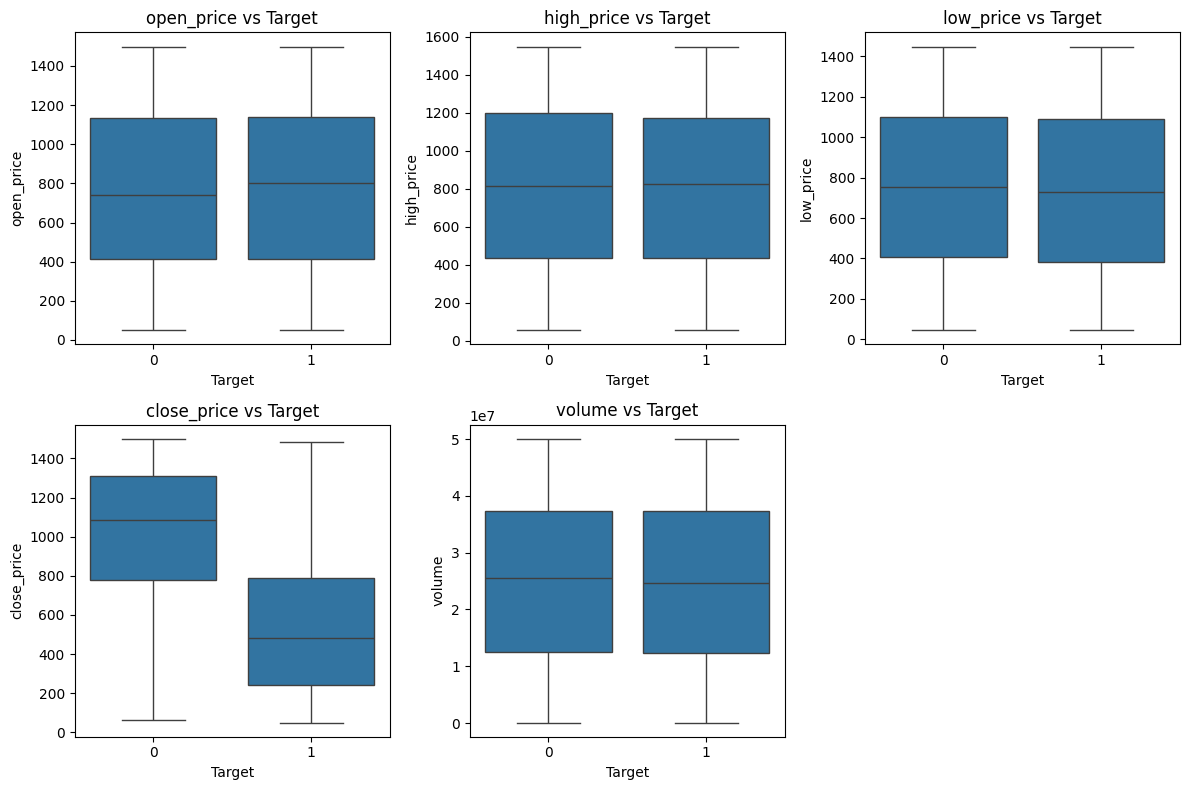

In [17]:
features = ["open_price", "high_price", "low_price", "close_price", "volume"]

plt.figure(figsize=(12,8))

for i, col in enumerate(features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(data=df, x="Target", y=col)
    plt.title(f"{col} vs Target")

plt.tight_layout()
plt.show()

A análise da relação entre as variáveis numéricas e a variável Target, por meio de boxplots, indica que os atributos open_price, high_price e low_price apresentam distribuições muito semelhantes entre as classes Alta (1) e Baixa (0), sem separação clara entre os grupos.

Em relação ao close_price, observa-se uma diferença mais evidente entre as distribuições das classes, o que é esperado, uma vez que a variável Target foi construída com base na variação futura desse atributo, estabelecendo uma relação direta entre eles.

Já o volume apresenta forte sobreposição entre as classes, sugerindo que, isoladamente, não possui forte poder discriminativo para separar os movimentos de alta e baixa.

De forma geral, os resultados indicam que não há separação linear clara entre as classes com base em variáveis individuais, reforçando a necessidade de modelos de Machine Learning capazes de capturar relações mais complexas entre os atributos.

Boxplots para investigar outliers
Visualizar possíveis outliers nas variáveis numéricas.


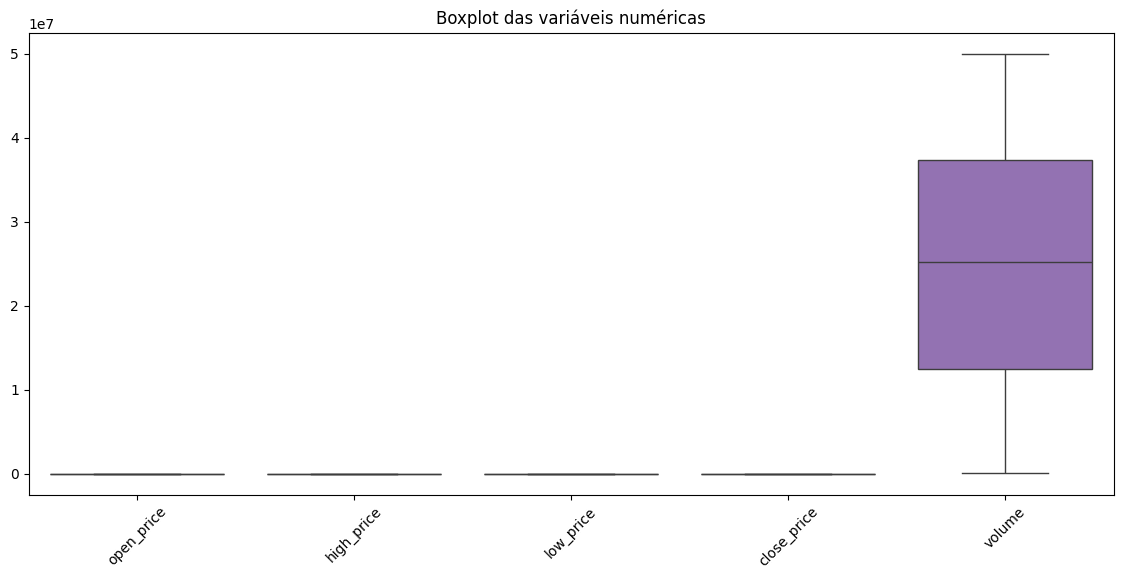

In [28]:
plt.figure(figsize=(14,6))
sns.boxplot(data=df[numeric_cols])
plt.title('Boxplot das variáveis numéricas')
plt.xticks(rotation=45)
plt.show()

Os boxplots permitem identificar valores extremos, especialmente em variáveis como volume, que podem apresentar comportamento bastante heterogêneo. Esse padrão deve ser considerado na escolha do pré-processamento e dos algoritmos utilizados.

Relação entre variáveis numéricas e target

Aqui começa a parte mais importante da EDA para classificação.

Objetivo

Ver se variáveis numéricas apresentam comportamento diferente entre Alta (1) e Baixa (0).

Código

Você pode fazer boxplots por target:

In [29]:
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='target', y=col, data=df)
    plt.title(f'{col} por classe do target')
    plt.show()

ValueError: Could not interpret value `target` for `x`. An entry with this name does not appear in `data`.

<Figure size 600x400 with 0 Axes>

A comparação das variáveis numéricas entre as classes do target ajuda a identificar se determinados atributos apresentam comportamentos distintos em cenários de alta e baixa. Quanto maior essa diferenciação, maior tende a ser o potencial preditivo da variável para o modelo.

Relação entre market_sentiment e target
Objetivo

Entender se o sentimento de mercado parece ter associação com alta/baixa.

Código

Se market_sentiment for categórica:

In [31]:
sns.boxplot(x='target', y='market_sentiment', data=df)
plt.title('Market Sentiment por target')
plt.show()

ValueError: Could not interpret value `target` for `x`. An entry with this name does not appear in `data`.

A análise de market_sentiment em relação ao target permite verificar se o sentimento de mercado está associado ao movimento futuro do ativo. Caso haja diferenças visíveis entre as classes, essa variável pode contribuir positivamente para a classificação.

Relação entre company e target
Objetivo

Verificar se empresas diferentes apresentam distribuições diferentes de alta/baixa.

In [32]:
company_target.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title('Distribuição do target por empresa')
plt.ylabel('Percentual')
plt.show()

NameError: name 'company_target' is not defined

A análise por empresa ajuda a verificar se diferentes ativos apresentam comportamentos distintos em relação ao target. Caso existam diferenças relevantes entre as distribuições, a variável company pode agregar valor preditivo ao modelo.

Relação temporal com date
Objetivo

Avaliar se existem padrões temporais simples.

Você não precisa fazer uma análise temporal super profunda, mas pode extrair:

ano
mês
dia da semana
Exemplo de criação

In [33]:
plt.figure(figsize=(10,4))
sns.countplot(x='month', hue='target', data=df)
plt.title('Distribuição do target por mês')
plt.show()

ValueError: Could not interpret value `month` for `x`. An entry with this name does not appear in `data`.

<Figure size 1000x400 with 0 Axes>

A extração de componentes temporais da variável date permite investigar se existem padrões sazonais ou comportamentos específicos ao longo do tempo. Caso sejam observadas diferenças relevantes, essas informações podem ser incorporadas ao modelo por meio de engenharia de atributos.

Matriz de correlação das variáveis numéricas
Objetivo

Ver relação entre variáveis numéricas e possível redundância entre atributos.

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlação das variáveis numéricas')
plt.show()

# Preparação dos dados e divisão treino/teste

## Justificativa da divisão

# Pré-processamento e pipeline

## Decisões de pré-processamento

#  Baseline e modelos candidatos

##  Justificativa dos modelos

# Treinamento e avaliação inicial